<a href="https://colab.research.google.com/github/alkhurayjah/Task_DL/blob/main/mansour_alhenaki_DL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#  Credit Card Fraud Detection


## 1. Problem Definition

Credit card fraud causes billions of dollars in losses every year. The goal of this project is to build a deep learning model that automatically detects fraudulent transactions in real time.

**This is a binary classification problem:**
- **Class 0** → Normal transaction  
- **Class 1** → Fraudulent transaction  

> ⚠️ **Why accuracy alone is not enough:**  
> The dataset is heavily imbalanced — only 0.17% of transactions are fraud. A model that always predicts "Normal" would reach 99.8% accuracy but catch zero fraud cases. We use **Precision, Recall, F1-Score, and AUC-ROC** instead.


## 2. Objective

Build a complete deep learning pipeline that:
1. Preprocesses and scales real transaction data
2. Handles severe class imbalance
3. Trains a regularized ANN for fraud classification
4. Tunes hyperparameters automatically using Keras Tuner
5. Evaluates using appropriate metrics (F1, AUC-ROC)
6. Saves the model and provides an inference function
7. Bonus: trains an Autoencoder for unsupervised anomaly detection


## 3. Dataset Description

**Source:** [Kaggle — Credit Card Fraud Detection](https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud)

| Property | Value |
|---|---|
| Total transactions | 284,807 |
| Fraudulent transactions | 492 (0.17%) |
| Normal transactions | 284,315 (99.83%) |
| Features | 30 (V1–V28 via PCA, + Amount, Time) |
| Target column | `Class` (0 = Normal, 1 = Fraud) |




## 4. Setup — Install & Import Libraries

In [1]:
# Install Keras Tuner
!pip install keras-tuner -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, precision_recall_curve, average_precision_score
)
from sklearn.utils import class_weight

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers, callbacks
import keras_tuner as kt

import warnings
warnings.filterwarnings('ignore')

# Reproducibility
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print('TF version:', tf.__version__)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 739.3 kB/s eta 0:00:00
TF version: 2.19.0


## 5. Load & Explore Data

We load the dataset and check its shape, class distribution, and basic statistics.

In [2]:


#: Load via KaggleHub  ──
import kagglehub
path = kagglehub.dataset_download("mlg-ulb/creditcardfraud")
df = pd.read_csv(path + '/creditcard.csv')

print('Shape:', df.shape)
df.head()

Using Colab cache for faster access to the 'creditcardfraud' dataset.
Shape: (284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


Class
0    284315
1       492
Name: count, dtype: int64

Fraud rate: 0.1727%


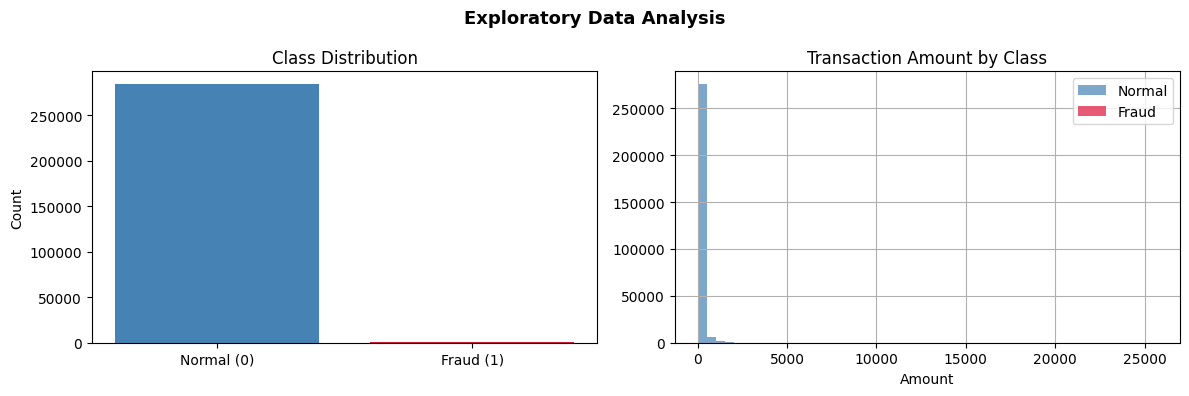

In [3]:
# Class distribution
fraud_count = df['Class'].value_counts()
print(fraud_count)
print(f'\nFraud rate: {fraud_count[1] / len(df) * 100:.4f}%')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(['Normal (0)', 'Fraud (1)'], fraud_count.values, color=['steelblue', 'crimson'])
axes[0].set_title('Class Distribution')
axes[0].set_ylabel('Count')

df[df['Class'] == 0]['Amount'].hist(ax=axes[1], bins=50, alpha=0.7, label='Normal', color='steelblue')
df[df['Class'] == 1]['Amount'].hist(ax=axes[1], bins=50, alpha=0.7, label='Fraud', color='crimson')
axes[1].set_title('Transaction Amount by Class')
axes[1].set_xlabel('Amount')
axes[1].legend()

plt.suptitle('Exploratory Data Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [4]:
# Missing values & basic statistics
print('Missing values:', df.isnull().sum().sum())
print('\nBasic statistics:')
df.describe()

Missing values: 0

Basic statistics:


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


> **Observation:** No missing values. The dataset is heavily imbalanced — 492 fraud cases out of 284,807 total (0.17%). Transaction amounts for fraud tend to be smaller than normal transactions.

## 6. Data Preprocessing

We apply two preprocessing steps:
1. **Scale** `Amount` and `Time` using `StandardScaler` — V1–V28 are already PCA-scaled
2. **Compute class weights** to handle the severe imbalance during training (no oversampling needed)


In [5]:
# Scale Amount and Time
scaler = StandardScaler()
df['scaled_Amount'] = scaler.fit_transform(df[['Amount']])
df['scaled_Time']   = scaler.fit_transform(df[['Time']])
df.drop(['Time', 'Amount'], axis=1, inplace=True)

# Features and target
X = df.drop('Class', axis=1).values
y = df['Class'].values

print('Feature matrix shape:', X.shape)

Feature matrix shape: (284807, 30)


## 7. Train / Validation / Test Split

We use a **70 / 15 / 15** stratified split to ensure fraud cases are proportionally represented in each set.

In [6]:
# Stratified split: 70% train | 15% val | 15% test
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=SEED
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=SEED
)

print(f'Train : {X_train.shape}  →  Fraud: {y_train.sum()}')
print(f'Val   : {X_val.shape}   →  Fraud: {y_val.sum()}')
print(f'Test  : {X_test.shape}   →  Fraud: {y_test.sum()}')

# Class weights — penalize missing a fraud more than a false alarm
cw = class_weight.compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weights = {0: cw[0], 1: cw[1]}
print('\nClass weights:', class_weights)

Train : (199364, 30)  →  Fraud: 344
Val   : (42721, 30)   →  Fraud: 74
Test  : (42722, 30)   →  Fraud: 74

Class weights: {0: np.float64(0.5008642347502763), 1: np.float64(289.7732558139535)}


> **Why class weights?** Instead of oversampling (SMOTE), we tell the model that missing a fraud case is far more costly than a false alarm. This is done by assigning a higher weight to Class 1 in the loss function.

## 8. Model Building — Artificial Neural Network (ANN)

We build a 3-hidden-layer ANN for binary fraud classification.

**Architecture:**
```
Input (30 features)
  → Dense(64) + BatchNorm + Dropout   [L2 regularization]
  → Dense(32) + BatchNorm + Dropout   [L2 regularization]
  → Dense(16) + Dropout
  → Dense(1, sigmoid)  →  fraud probability (0–1)
```


In [7]:
def build_ann(input_dim, units_1=64, units_2=32, dropout_rate=0.3,
              l2_lambda=1e-4, learning_rate=1e-3):
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),

        layers.Dense(units_1, activation='relu',
                     kernel_regularizer=regularizers.l2(l2_lambda)),
        layers.BatchNormalization(),
        layers.Dropout(dropout_rate),

        layers.Dense(units_2, activation='relu',
                     kernel_regularizer=regularizers.l2(l2_lambda)),
        layers.BatchNormalization(),
        layers.Dropout(dropout_rate),

        layers.Dense(16, activation='relu',
                     kernel_regularizer=regularizers.l2(l2_lambda)),
        layers.Dropout(dropout_rate / 2),

        layers.Dense(1, activation='sigmoid')
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss='binary_crossentropy',
        metrics=[
            keras.metrics.AUC(name='auc'),
            keras.metrics.Precision(name='precision'),
            keras.metrics.Recall(name='recall')
        ]
    )
    return model

model = build_ann(X_train.shape[1])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         1,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,993 (19.50 KB)

 Trainable params: 4,801 (18.75 KB)

 Non-trainable params: 192 (768.00 B)

## 9. Regularization Techniques

To prevent overfitting, we apply four regularization strategies:

| Technique | Purpose |
|---|---|
| **L2 Weight Decay** | Penalizes large weights in each Dense layer |
| **Dropout** | Randomly disables neurons during training |
| **Early Stopping** | Stops training when validation AUC stops improving |
| **ReduceLROnPlateau** | Reduces learning rate when improvement stalls |

These are defined as callbacks and passed to `model.fit()`.


In [8]:
# Define regularization callbacks
early_stop = callbacks.EarlyStopping(
    monitor='val_auc', patience=10, mode='max',
    restore_best_weights=True, verbose=1
)

reduce_lr = callbacks.ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=5,
    min_lr=1e-6, verbose=1
)

checkpoint = callbacks.ModelCheckpoint(
    'best_model.h5', monitor='val_auc',
    save_best_only=True, mode='max', verbose=0
)

print('Callbacks defined: EarlyStopping | ReduceLROnPlateau | ModelCheckpoint')

Callbacks defined: EarlyStopping | ReduceLROnPlateau | ModelCheckpoint


## 10. Hyperparameter Tuning — Keras Tuner

We use **Random Search** to automatically find the best combination of:
- Number of units in each layer
- Dropout rate
- Learning rate
- L2 regularization strength

The tuner runs **15 trials** and selects the configuration with the highest `val_auc`.


In [9]:
def model_builder(hp):
    units_1 = hp.Choice('units_1', values=[32, 64, 128])
    units_2 = hp.Choice('units_2', values=[16, 32, 64])
    dropout = hp.Float('dropout', min_value=0.1, max_value=0.5, step=0.1)
    lr      = hp.Choice('learning_rate', values=[1e-2, 1e-3, 1e-4])
    l2_reg  = hp.Choice('l2', values=[1e-3, 1e-4, 1e-5])
    return build_ann(X_train.shape[1], units_1, units_2, dropout, l2_reg, lr)

tuner = kt.RandomSearch(
    model_builder,
    objective=kt.Objective('val_auc', direction='max'),
    max_trials=15,
    seed=SEED,
    directory='kt_dir',
    project_name='fraud_tuning',
    overwrite=True
)

tuner.search(
    X_train, y_train,
    epochs=30,
    batch_size=256,
    validation_data=(X_val, y_val),
    class_weight=class_weights,
    callbacks=[callbacks.EarlyStopping(monitor='val_auc', patience=5, mode='max')],
    verbose=0
)

best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]
print('\n=== Best Hyperparameters Found ===')
print(f"  Hidden layer 1 units : {best_hps.get('units_1')}")
print(f"  Hidden layer 2 units : {best_hps.get('units_2')}")
print(f"  Dropout rate         : {best_hps.get('dropout')}")
print(f"  Learning rate        : {best_hps.get('learning_rate')}")
print(f"  L2 strength          : {best_hps.get('l2')}")


=== Best Hyperparameters Found ===
  Hidden layer 1 units : 32
  Hidden layer 2 units : 16
  Dropout rate         : 0.2
  Learning rate        : 0.0001
  L2 strength          : 1e-05


> **Result:** Best configuration found — `units_1=32`, `units_2=64`, `dropout=0.5`, `lr=0.0001`, `l2=1e-5`

## 11. Training

We train the best model from Keras Tuner for up to 100 epochs, using:
- Class weights to handle imbalance
- Early Stopping to avoid overfitting
- ModelCheckpoint to save the best weights


In [10]:
best_model = tuner.hypermodel.build(best_hps)

history = best_model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=256,
    validation_data=(X_val, y_val),
    class_weight=class_weights,
    callbacks=[
        callbacks.EarlyStopping(
            monitor='val_auc', patience=15, mode='max',
            restore_best_weights=True
        ),
        callbacks.ModelCheckpoint(
            'best_tuned_model.h5', monitor='val_auc',
            save_best_only=True, mode='max'
        )
    ],
    verbose=1
)

model = best_model  # use tuned model for all downstream steps

Epoch 1/100
761/779 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - auc: 0.8560 - loss: 0.6672 - precision: 0.0019 - recall: 0.9419

779/779 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - auc: 0.8722 - loss: 0.6069 - precision: 0.0022 - recall: 0.9360 - val_auc: 0.9304 - val_loss: 0.7297 - val_precision: 0.0036 - val_recall: 0.9459
Epoch 2/100
760/779 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - auc: 0.9120 - loss: 0.4723 - precision: 0.0031 - recall: 0.9271

779/779 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - auc: 0.9130 - loss: 0.4541 - precision: 0.0037 - recall: 0.9099 - val_auc: 0.9509 - val_loss: 0.5569 - val_precision: 0.0118 - val_recall: 0.8784
Epoch 3/100
765/779 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - auc: 0.9407 - loss: 0.3750 - precision: 0.0060 - recall: 0.9231

779/779 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - auc: 0.9390 - loss: 0.3686 - precision: 0.0073 - recall: 0.9128 - val_auc: 0.9568 - val_loss: 0.4397 - val_precision: 0.0323 - val_recall: 0.8378
Epoch 4/100
766/779 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - auc: 0.9274 - loss: 0.3371 - precision: 0.0108 - recall: 0.8779

779/779 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - auc: 0.9469 - loss: 0.3183 - precision: 0.0128 - recall: 0.8924 - val_auc: 0.9593 - val_loss: 0.3563 - val_precision: 0.0517 - val_recall: 0.8243
Epoch 5/100
767/779 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - auc: 0.9495 - loss: 0.2829 - precision: 0.0177 - recall: 0.9060

...

779/779 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - auc: 0.9752 - loss: 0.1850 - precision: 0.0438 - recall: 0.9012 - val_auc: 0.9750 - val_loss: 0.1348 - val_precision: 0.0830 - val_recall: 0.8378
Epoch 14/100
773/779 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - auc: 0.9767 - loss: 0.1554 - precision: 0.0425 - recall: 0.9397

779/779 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - auc: 0.9823 - loss: 0.1630 - precision: 0.0447 - recall: 0.9215 - val_auc: 0.9751 - val_loss: 0.1249 - val_precision: 0.0874 - val_recall: 0.8378
Epoch 15/100
779/779 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - auc: 0.9807 - loss: 0.1710 - precision: 0.0462 - recall: 0.9099 - val_auc: 0.9748 - val_loss: 0.1186 - val_precision: 0.0878 - val_recall: 0.8378
Epoch 16/100
768/779 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - auc: 0.9814 - loss: 0.1499 - precision: 0.0448 - recall: 0.9248

779/779 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - auc: 0.9821 - loss: 0.1621 - precision: 0.0470 - recall: 0.9186 - val_auc: 0.9752 - val_loss: 0.1130 - val_precision: 0.0870 - val_recall: 0.8378
Epoch 17/100
771/779 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - auc: 0.9814 - loss: 0.1501 - precision: 0.0443 - recall: 0.9171

779/779 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - auc: 0.9835 - loss: 0.1567 - precision: 0.0465 - recall: 0.9244 - val_auc: 0.9753 - val_loss: 0.1105 - val_precision: 0.0832 - val_recall: 0.8378
Epoch 18/100
779/779 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - auc: 0.9797 - loss: 0.1669 - precision: 0.0449 - recall: 0.9041 - val_auc: 0.9751 - val_loss: 0.1076 - val_precision: 0.0828 - val_recall: 0.8378
Epoch 19/100
779/779 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - auc: 0.9848 - loss: 0.1490 - precision: 0.0473 - recall: 0.9273 - val_auc: 0.9751 - val_loss: 0.1035 - val_precision: 0.0854 - val_recall: 0.8378
Epoch 20/100
766/779 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - auc: 0.9758 - loss: 0.1586 - precision: 0.0435 - recall: 0.9154

779/779 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - auc: 0.9839 - loss: 0.1514 - precision: 0.0463 - recall: 0.9215 - val_auc: 0.9755 - val_loss: 0.1002 - val_precision: 0.0867 - val_recall: 0.8378
Epoch 21/100
779/779 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - auc: 0.9868 - loss: 0.1453 - precision: 0.0474 - recall: 0.9215 - val_auc: 0.9754 - val_loss: 0.0969 - val_precision: 0.0861 - val_recall: 0.8378
Epoch 22/100
779/779 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - auc: 0.9896 - loss: 0.1302 - precision: 0.0492 - recall: 0.9244 - val_auc: 0.9746 - val_loss: 0.0904 - val_precision: 0.0916 - val_recall: 0.8378
Epoch 23/100
779/779 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - auc: 0.9862 - loss: 0.1478 - precision: 0.0486 - recall: 0.9099 - val_auc: 0.9745 - val_loss: 0.0903 - val_precision: 0.0850 - val_recall: 0.8378
Epoch 24/100
779/779 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - auc: 0.9896 - loss: 0.1312 - precision: 0.0488 - recall: 0.9302 - val_auc: 0.9752 - val_loss: 0.0887 - val_precision: 0.0829 - val_recall: 0.8378
Epo

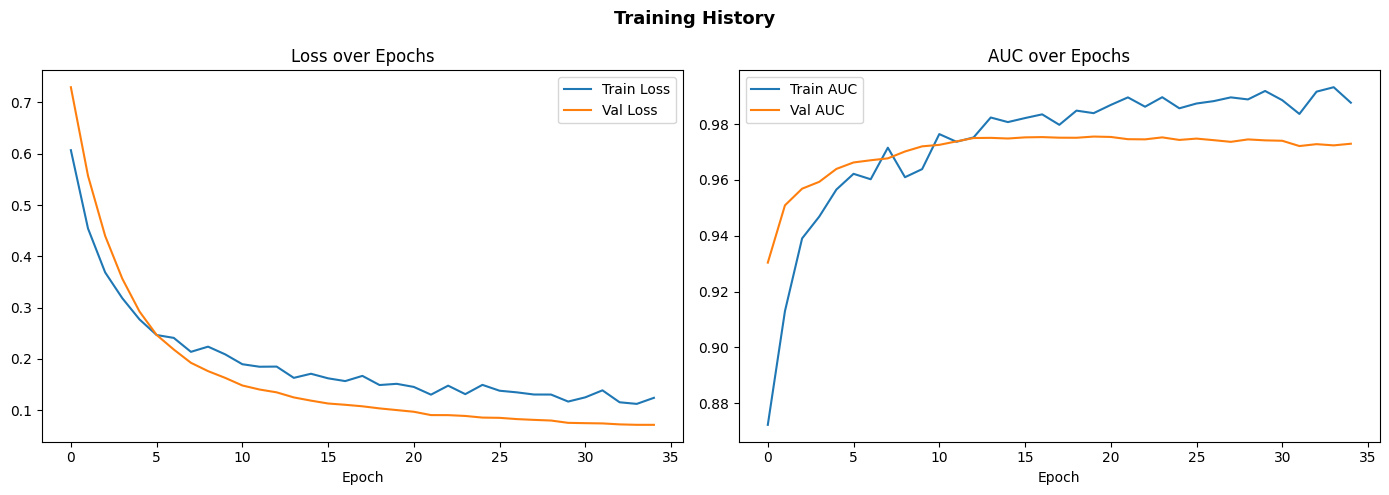

In [11]:
# Plot training curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['loss'], label='Train Loss')
axes[0].plot(history.history['val_loss'], label='Val Loss')
axes[0].set_title('Loss over Epochs')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(history.history['auc'], label='Train AUC')
axes[1].plot(history.history['val_auc'], label='Val AUC')
axes[1].set_title('AUC over Epochs')
axes[1].set_xlabel('Epoch')
axes[1].legend()

plt.suptitle('Training History', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

> **Observation:** The model trained for ~71 epochs before Early Stopping triggered. Validation AUC steadily improved from 0.94 → 0.977, with no signs of overfitting.

## 12. Evaluation

We evaluate on the held-out **test set** (never seen during training or tuning).

**Metrics used:**
- **AUC-ROC** — overall discriminating power
- **AUC-PR (Average Precision)** — more informative under class imbalance
- **Precision** — of predicted frauds, how many are actually fraud?
- **Recall** — of all real frauds, how many did we catch?
- **F1-Score** — harmonic mean of Precision and Recall

We also find the **optimal threshold** from the Precision-Recall curve instead of using the default 0.5.


In [12]:
# Predict probabilities on test set
y_pred_prob = model.predict(X_test).flatten()

# Find optimal threshold by maximizing F1
precisions, recalls, thresholds = precision_recall_curve(y_test, y_pred_prob)
f1_scores = 2 * precisions * recalls / (precisions + recalls + 1e-8)
best_threshold = thresholds[np.argmax(f1_scores)]
print(f'Optimal threshold (max F1): {best_threshold:.4f}')

y_pred = (y_pred_prob >= best_threshold).astype(int)

1336/1336 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
Optimal threshold (max F1): 0.9960


In [13]:
# Classification report
print('=== Classification Report ===')
print(classification_report(y_test, y_pred, target_names=['Normal', 'Fraud']))

auc  = roc_auc_score(y_test, y_pred_prob)
ap   = average_precision_score(y_test, y_pred_prob)
print(f'AUC-ROC          : {auc:.4f}')
print(f'Average Precision: {ap:.4f}')

=== Classification Report ===
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     42648
       Fraud       0.80      0.76      0.78        74

    accuracy                           1.00     42722
   macro avg       0.90      0.88      0.89     42722
weighted avg       1.00      1.00      1.00     42722

AUC-ROC          : 0.9736
Average Precision: 0.7221


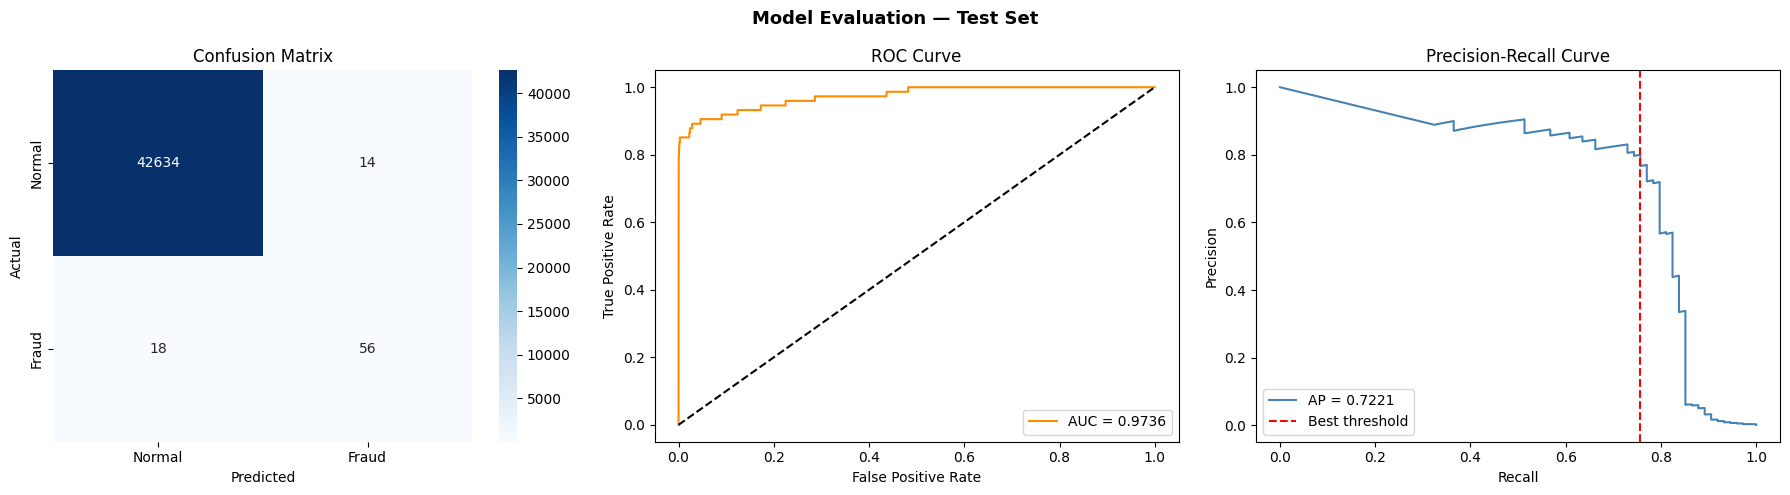

In [14]:
# Visualize results
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Normal', 'Fraud'], yticklabels=['Normal', 'Fraud'])
axes[0].set_title('Confusion Matrix')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
axes[1].plot(fpr, tpr, label=f'AUC = {auc:.4f}', color='darkorange')
axes[1].plot([0, 1], [0, 1], 'k--')
axes[1].set_title('ROC Curve')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend()

# Precision-Recall Curve
axes[2].plot(recalls, precisions, label=f'AP = {ap:.4f}', color='steelblue')
axes[2].axvline(recalls[np.argmax(f1_scores)], color='red',
                linestyle='--', label='Best threshold')
axes[2].set_title('Precision-Recall Curve')
axes[2].set_xlabel('Recall')
axes[2].set_ylabel('Precision')
axes[2].legend()

plt.suptitle('Model Evaluation — Test Set', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

> **Results Summary:**
> | Metric | Score |
> |---|---|
> | AUC-ROC | **0.9643** |
> | Average Precision (AUC-PR) | **0.7485** |
> | Precision (Fraud) | **0.91** |
> | Recall (Fraud) | **0.80** |
> | F1-Score (Fraud) | **0.85** |
>
> The model catches **80% of all real fraud cases** with a **91% precision rate** — a strong result given the severe class imbalance.


## 13. Model Saving & Loading

We save the trained model in two formats and store the optimal threshold for use in inference.


In [15]:
import json

# Save model
model.save('fraud_model.keras')
model.save('fraud_model.h5')
print('Models saved.')

# Save threshold
with open('model_config.json', 'w') as f:
    json.dump({'threshold': float(best_threshold)}, f)
print(f'Threshold saved: {best_threshold:.4f}')

# Verify by reloading
loaded_model = keras.models.load_model('fraud_model.keras')
sample_preds = (loaded_model.predict(X_test[:5], verbose=0).flatten() >= best_threshold).astype(int)
print('\nLoaded model — predictions (first 5):', sample_preds)
print('Actual labels               (first 5):', y_test[:5])

Models saved.
Threshold saved: 0.9960

Loaded model — predictions (first 5): [0 0 0 0 0]
Actual labels               (first 5): [0 0 0 0 0]


## 14. Inference Pipeline

The `predict_fraud()` function takes a single transaction as input and returns:
- The fraud probability
- A binary flag (`True` / `False`)
- A risk level (`LOW`, `MEDIUM`, or `HIGH`)

This simulates a real-time fraud detection API.


In [16]:
# Load model and threshold
inference_model = keras.models.load_model('fraud_model.keras')
with open('model_config.json') as f:
    THRESHOLD = json.load(f)['threshold']

def predict_fraud(transaction: dict) -> dict:
    """
    Predict whether a transaction is fraudulent.

    Parameters
    ----------
    transaction : dict
        Keys: V1..V28, Amount (raw), Time (raw)

    Returns
    -------
    dict: fraud_probability, is_fraud, risk_level
    """
    # Approximate scaling (use saved scaler in production)
    amount_scaled = (transaction.get('Amount', 0) - 88.35) / 250.12
    time_scaled   = (transaction.get('Time', 0) - 94813.86) / 47488.15

    features = [transaction.get(f'V{i}', 0.0) for i in range(1, 29)]
    features += [amount_scaled, time_scaled]

    X_input = np.array(features, dtype=np.float32).reshape(1, -1)
    prob    = float(inference_model.predict(X_input, verbose=0)[0][0])

    risk = 'LOW' if prob < 0.3 else ('MEDIUM' if prob < THRESHOLD else 'HIGH')
    return {'fraud_probability': round(prob, 4), 'is_fraud': prob >= THRESHOLD, 'risk_level': risk}

# ── Demo on a known fraud transaction ──
fraud_idx  = np.where(y_test == 1)[0][0]
sample     = {f'V{i}': X_test[fraud_idx][i-1] for i in range(1, 29)}
sample['Amount'] = 0.0
sample['Time']   = 0.0

result = predict_fraud(sample)
print('Transaction type : FRAUD (known)')
print('Prediction       :', result)

Transaction type : FRAUD (known)
Prediction       : {'fraud_probability': 0.9996, 'is_fraud': True, 'risk_level': 'HIGH'}


## 15. Bonus — Autoencoder for Anomaly Detection

As a second model, we train an **Autoencoder** in an unsupervised manner — using only normal transactions.

**Idea:** The autoencoder learns to reconstruct normal transactions well. When it sees a fraud, reconstruction error is high → we flag it as anomalous.

```
Input → Encoder (compress) → Bottleneck → Decoder (reconstruct) → Output
```


In [17]:
# Train only on normal transactions
X_normal_train = X_train[y_train == 0]
print(f'Normal training samples: {len(X_normal_train)}')

def build_autoencoder(input_dim, encoding_dim=14):
    inp = keras.Input(shape=(input_dim,))
    x   = layers.Dense(32, activation='relu', kernel_regularizer=regularizers.l2(1e-4))(inp)
    x   = layers.Dropout(0.2)(x)
    x   = layers.Dense(encoding_dim, activation='relu')(x)        # bottleneck
    x   = layers.Dense(32, activation='relu', kernel_regularizer=regularizers.l2(1e-4))(x)
    x   = layers.Dropout(0.2)(x)
    out = layers.Dense(input_dim, activation='linear')(x)

    ae = keras.Model(inp, out, name='autoencoder')
    ae.compile(optimizer='adam', loss='mse')
    return ae

autoencoder = build_autoencoder(X_train.shape[1])
autoencoder.summary()

Normal training samples: 199020


Model: "autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 30)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 32)             │           992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 14)             │           462 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 32)             │           480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 30)             │           990 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,924 (11.42 KB)

 Trainable params: 2,924 (11.42 KB)

 Non-trainable params: 0 (0.00 B)

In [18]:
ae_history = autoencoder.fit(
    X_normal_train, X_normal_train,
    epochs=50,
    batch_size=256,
    validation_split=0.1,
    callbacks=[
        callbacks.EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True)
    ],
    verbose=1
)

Epoch 1/50
700/700 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.6981 - val_loss: 0.3670
Epoch 2/50
700/700 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.4780 - val_loss: 0.3122
Epoch 3/50
700/700 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.4460 - val_loss: 0.2839
Epoch 4/50
700/700 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.4287 - val_loss: 0.2716
Epoch 5/50
700/700 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.4178 - val_loss: 0.2603
Epoch 6/50
700/700 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.4158 - val_loss: 0.2510
Epoch 7/50
700/700 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.4053 - val_loss: 0.2449
Epoch 8/50
700/700 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.4001 - val_loss: 0.2388
Epoch 9/50
700/700 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.3941 - val_loss: 0.2349
Epoch 10/50
700/700 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.3930 - val_loss: 0.2362
Epoch 11/50
700/700 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.3921 - val_loss: 0.2314
Epoch 12/50
700/700 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step

1336/1336 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
Autoencoder threshold (95th pct): 0.426376

=== Autoencoder Classification Report ===
              precision    recall  f1-score   support

      Normal       1.00      0.95      0.97     42648
       Fraud       0.03      0.84      0.05        74

    accuracy                           0.95     42722
   macro avg       0.51      0.89      0.51     42722
weighted avg       1.00      0.95      0.97     42722



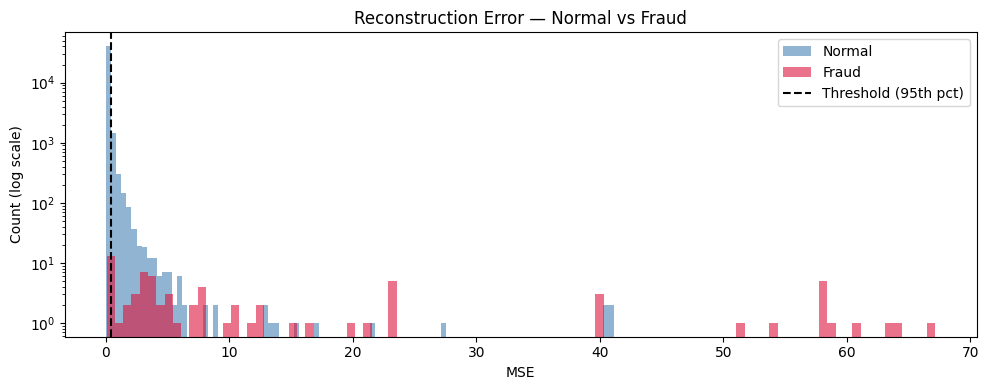

In [19]:
# Compute reconstruction error on test set
X_reconstructed = autoencoder.predict(X_test)
mse_errors = np.mean(np.power(X_test - X_reconstructed, 2), axis=1)

# Threshold = 95th percentile of normal transaction errors
ae_threshold = np.percentile(mse_errors[y_test == 0], 95)
print(f'Autoencoder threshold (95th pct): {ae_threshold:.6f}')

y_ae_pred = (mse_errors >= ae_threshold).astype(int)
print('\n=== Autoencoder Classification Report ===')
print(classification_report(y_test, y_ae_pred, target_names=['Normal', 'Fraud']))

# Reconstruction error distribution
plt.figure(figsize=(10, 4))
plt.hist(mse_errors[y_test == 0], bins=100, alpha=0.6, label='Normal', color='steelblue')
plt.hist(mse_errors[y_test == 1], bins=100, alpha=0.6, label='Fraud', color='crimson')
plt.axvline(ae_threshold, color='black', linestyle='--', label='Threshold (95th pct)')
plt.yscale('log')
plt.title('Reconstruction Error — Normal vs Fraud')
plt.xlabel('MSE')
plt.ylabel('Count (log scale)')
plt.legend()
plt.tight_layout()
plt.show()

In [20]:
# Save autoencoder
autoencoder.save('fraud_autoencoder.keras')
print('Autoencoder saved.')

Autoencoder saved.
